<h3 style="color:skyblue">Question 1: Import the required Python libraries for time series analysis.</h3>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<h3 style="color:skyblue"> Question 2: Load the dataset into a Pandas DataFrame.</h3>

In [2]:
data = pd.read_csv('sales.csv')

<h3 style="color:skyblue">Question 3: Display the first few rows and list the column names. </h3>

In [3]:
print('The column names are: ', data.columns)
data.head()
data.dropna(inplace=True)

The column names are:  Index(['date', 'sales'], dtype='object')


<h3 style="color:skyblue">Question 4: Convert the Date column into a proper datetime format. </h3>

In [4]:
data['date'] = pd.to_datetime(data['date'])
data.dtypes

date     datetime64[ns]
sales           float64
dtype: object

<h3 style="color:skyblue">Question 5: Set the Date column as the time index of the DataFrame. </h3>

In [5]:
data.set_index('date', inplace=True)
data

,sales
date,
2025-01-01 00:00:00,403.465314
2025-01-01 01:00:00,435.826090
2025-01-01 02:00:00,403.965471
2025-01-01 03:00:00,387.312635
2025-01-01 04:00:00,383.843844
...,...
2025-07-02 07:00:00,1093.690692
2025-07-02 08:00:00,1159.299127
2025-07-02 09:00:00,1171.325003


<h3 style="color:skyblue">Question 6: Check for missing or invalid values and handle them appropriately. </h3>

In [6]:
data.dtypes
data.isna().sum()

sales    0
dtype: int64

<h3 style="color:skyblue">Question 7: Select sales as the target variable and create a daily or monthly aggregated time series. </h3>

In [7]:
data_daily = data[['sales']].resample('D').mean()
data_monthly = data[['sales']].resample('m').mean()
data_daily
data_monthly

,sales
date,
2025-01-31,446.233200
2025-02-28,526.534607
2025-03-31,600.356847
2025-04-30,702.816880
2025-05-31,823.510203
2025-06-30,894.248052
2025-07-31,873.676906


<h3 style="color:skyblue">Question 8: Plot the time series using a line chart with proper title and axis labels.</h3>

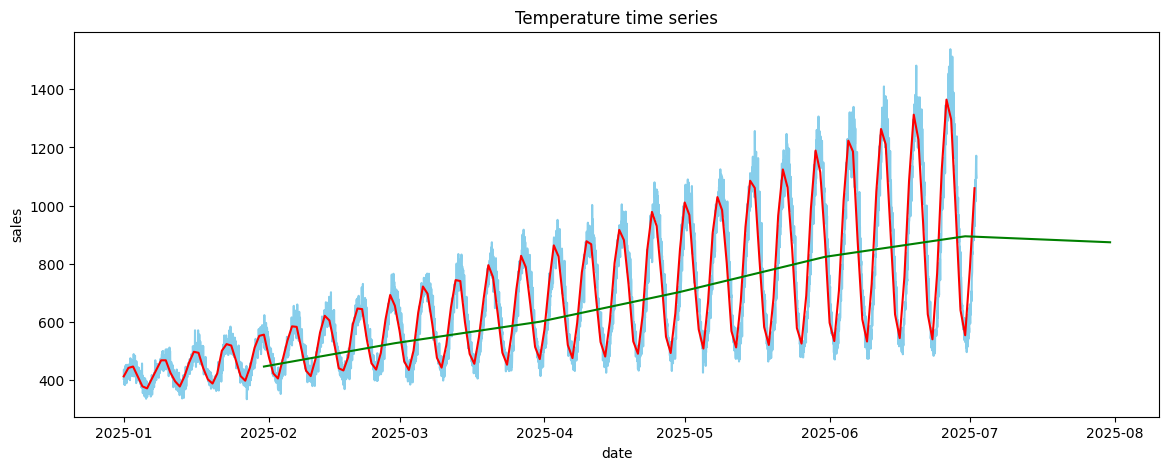

In [8]:
plt.figure(figsize=(14, 5))
sns.lineplot(x=data.index, y=data['sales'], color='skyblue')
sns.lineplot(x=data_daily.index, y=data_daily['sales'], color='red')
sns.lineplot(x=data_monthly.index, y=data_monthly['sales'], color='green')

plt.title('Temperature time series')
plt.show()

<h3 style="color:skyblue">Question 9: Apply additive decomposition to the time series and display its components. </h3>

<function matplotlib.pyplot.show(close=None, block=None)>

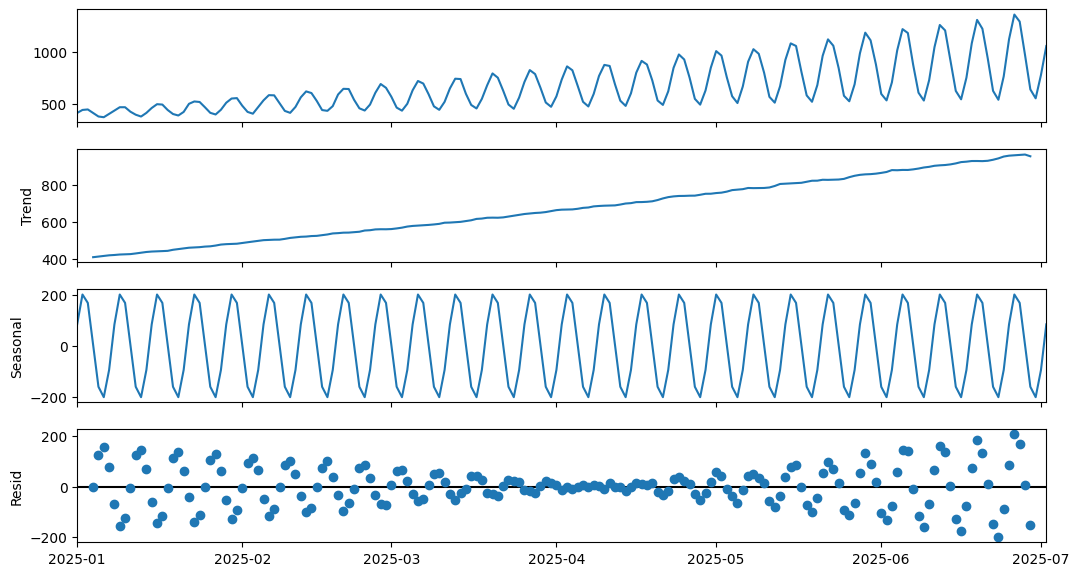

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
period = 7
add_decomp = seasonal_decompose(data_daily, model='additive', period=period)
fig = add_decomp.plot()
fig.set_size_inches(12, 6)
plt.show

<h3 style="color:skyblue">Question 10: Apply multiplicative decomposition to the time series and display its components. </h3>

<function matplotlib.pyplot.show(close=None, block=None)>

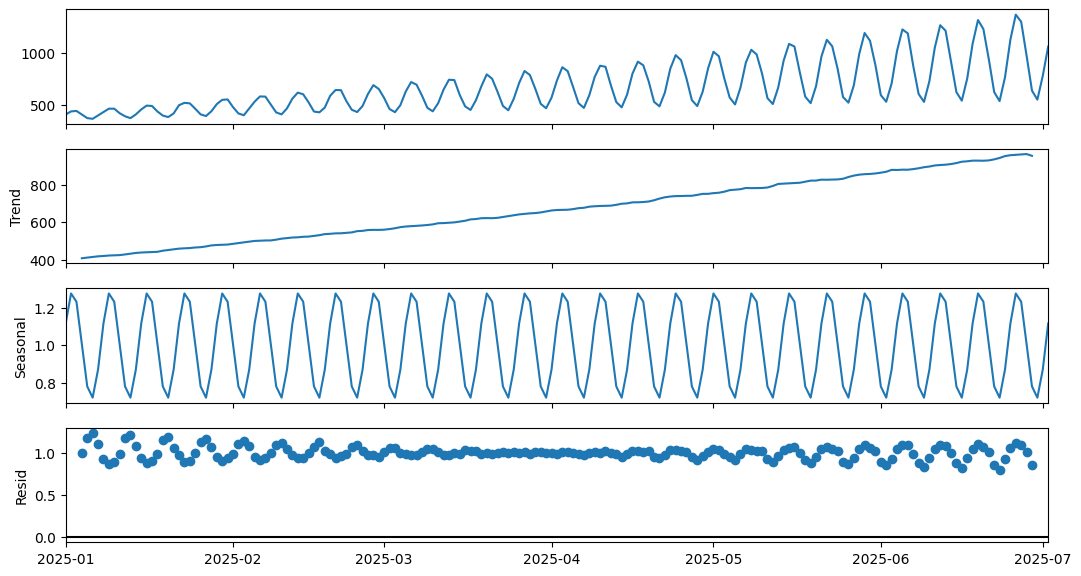

In [10]:
period = 7
add_decomp = seasonal_decompose(data_daily, model='multiplicative', period=period)
fig = add_decomp.plot()
fig.set_size_inches(12, 6)
plt.show

<h3 style="color:skyblue">Question 11: Briefly state which decomposition model is more suitable for this dataset and justify your answer in 1–2 lines. </h3>

<h3 style="color:skyblue">Question 12: Convert the aggregated data into a time-series DataFrame with a proper date/time index.</h3>

<h3 style="color:skyblue">Question 14: Apply Simple Moving Average (SMA) using one window size (e.g., 3-period or 6-period). </h3>

In [11]:
window_size = 7
data_daily['sma6'] = data_daily['sales'].rolling(window=window_size).mean()
data_daily = data_daily[~data_daily.index.duplicated(keep='first')]

<h3 style="color:skyblue">Question 15: Plot the original and the smoothed time series. </h3>

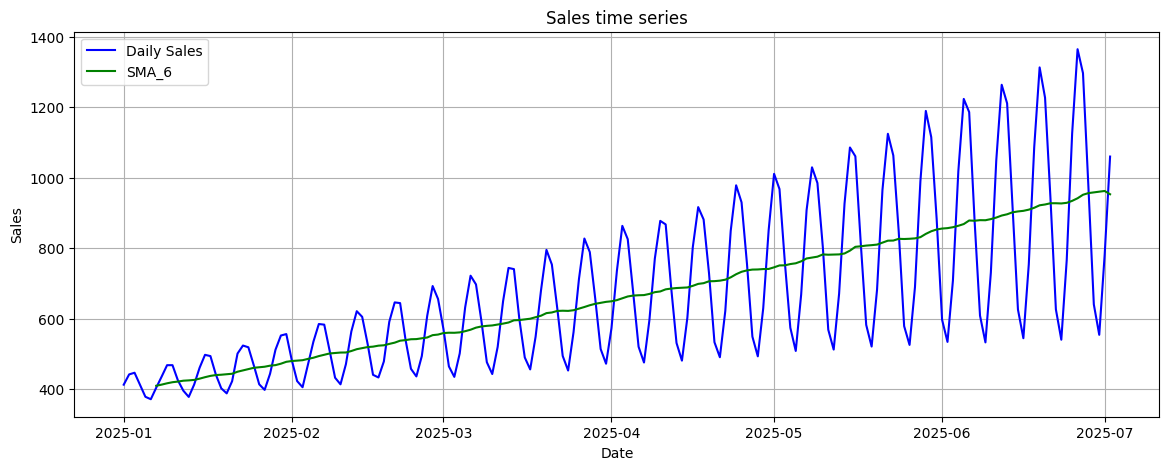

In [12]:
plt.figure(figsize=(14, 5))
sns.lineplot(x=data_daily.index, y=data_daily['sales'], color='blue', label='Daily Sales')
sns.lineplot(x=data_daily.index, y=data_daily['sma6'], color='green', label='SMA_6')
plt.title('Sales time series')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

<h3 style="color:skyblue">Question 16: Briefly state (1–2 lines) the purpose of applying SMA in time-series analysis. </h3>

Simple Moving Average is used to smooth short-term fluctuations and random noise in a time series, making the overall pattern more stable. This helps in clearly identifying the underlying trend and general direction of the data over time.

<h3 style="color:skyblue">Question 17: 1.	Apply Holt’s method to capture the level and trend of the time series. </h3>

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
ts = data_daily['sales'].dropna()
holt_model = Holt(ts).fit()
holt_fitted = holt_model.fittedvalues

<h3 style="color:skyblue">Question 18: Apply the Holt–Winters method to capture level, trend, and seasonality. </h3>

In [14]:
hw_model = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=10).fit()
hw_fitted = hw_model.fittedvalues

<h3 style="color:skyblue">Question 19: Plot the following the original, holt, and holt_winters time series. </h3>

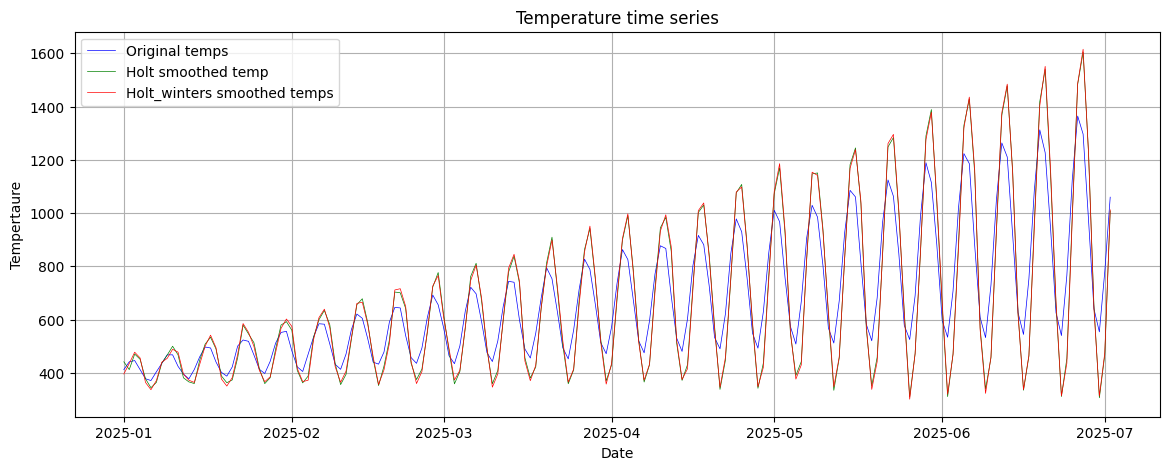

In [15]:
plt.figure(figsize=(14, 5))
sns.lineplot(x=ts.index, y=ts.values, color='blue', label='Original temps', linewidth=0.5)
sns.lineplot(x=holt_fitted.index, y=holt_fitted.values, color='green', label='Holt smoothed temp', linewidth=0.5)
sns.lineplot(x=hw_fitted.index, y=hw_fitted.values, color='red', label='Holt_winters smoothed temps', linewidth=0.5)

plt.title('Temperature time series')
plt.xlabel('Date')
plt.ylabel('Tempertaure')
plt.legend()
plt.grid(True)
plt.show()

<h3 style="color:skyblue">Question 20: Briefly compare the smoothing results and state which method better represents the data, with a short justification (2–3 lines). </h3>

Holt’s method captures the overall level and trend of the series but does not model repeating seasonal patterns. Holt–Winters better represents the data because it captures level, trend, and seasonality, which are clearly present in the time series.